# Deep Neural Network for Bank Customer Churn Prediction

**Capstone Project**  
**Business domain:** Digital banking / customer retention  
**Primary goal:** predict customers at risk of churn early enough to support proactive retention actions.

---

## Executive Summary

This project builds a neural-network-based churn scoring system for a bank. The model estimates the probability that each customer will churn and converts this probability into an operational retention list.

The final model achieves strong ranking quality on the holdout test set:

- **ROC-AUC:** 0.8574
- **PR-AUC:** 0.6975
- **Recall at selected threshold:** 0.7174
- **Precision at selected threshold:** 0.5290
- **Contact rate:** 27.6% of customers
- **Top risk decile churn rate:** 80.0%, compared with the average test churn rate of 20.35%

The model is useful because it does not simply predict a class label. It supports a complete business workflow:

1. score every customer by churn risk;
2. rank customers from highest to lowest risk;
3. select a threshold based on retention economics;
4. create a targeted retention campaign list;
5. estimate potential business impact;
6. explain the main drivers of model predictions.

**Capstone rubric coverage:**

1. **Problem Statement:** bank customer churn and proactive retention.
2. **Data:** public operational-style customer-level banking dataset with CRM-like features.
3. **Modeling Approach:** deep MLP neural network with dropout, weighted loss, early stopping, and threshold optimization.
4. **KPI & Success:** ROC-AUC as the primary metric, supported by recall, PR-AUC, F1-score, lift, and business impact simulation.

**Important note:** the business impact calculation uses explicit assumptions about customer value, retention cost, and retention success rate. These assumptions should be replaced with real bank economics before production deployment.


# 1. Problem Statement

## What business problem are we solving?

Banks and fintech companies need to identify customers who are likely to churn before they actually leave. Churn means that a customer stops using the bank's products or moves their financial activity to another provider.

The business problem is therefore:

> **Predict customer churn probability and prioritize high-risk customers for targeted retention actions.**

This is a high-value problem because retention teams cannot contact every customer. A predictive model helps allocate retention budget to the customers with the highest expected risk and business value.

## Why does it matter now?

Modern banking is highly competitive. Digital onboarding, mobile banking, fintech apps, and low switching costs make it easier for customers to move between providers. As a result, banks need early warning systems that can detect risk signals in customer behavior.

A useful churn model should answer three questions:

1. **Who is likely to churn?**
2. **How confident is the model?**
3. **Which customer groups or features drive the risk?**

The final output of this project is a customer-level churn score that can be used by CRM, marketing, and customer success teams.

# 2. Data

## Dataset

The project uses the **Bank Customer Churn Prediction Dataset** from Kaggle. The data contains structured customer-level records similar to what a bank CRM or customer analytics system could store.

Each row represents one customer. The target variable is binary:

- `churn = 1`: the customer exited / churned,
- `churn = 0`: the customer stayed.

## Feature groups

The dataset contains several business-relevant feature groups:

| Group | Examples | Business meaning |
|---|---|---|
| Demographics | `age`, `gender`, `country` | customer segment and market context |
| Financial profile | `credit_score`, `balance`, `estimated_salary` | financial capacity and relationship value |
| Product usage | `products_number`, `credit_card` | depth of relationship with the bank |
| Engagement | `active_member`, `tenure` | activity and loyalty signals |

## Reliability / representativeness

This is a public operational-style dataset rather than a toy dataset. It is not organization-owned by our team, but it resembles real banking CRM data because it contains aggregated customer-level variables commonly used in churn monitoring and retention decisioning.

Important modeling note: `customer_id` is excluded from training because it is only an identifier and has no generalizable predictive meaning.

In [1]:
# Core libraries
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

print('PyTorch version:', torch.__version__)

PyTorch version: 2.11.0+cu128


In [2]:
# Load data
# The notebook searches for the dataset in common locations.
from pathlib import Path
import pandas as pd

possible_paths = [
    Path('Bank Customer Churn Prediction.csv'),
    Path('/content/Bank Customer Churn Prediction.csv'),
    Path('/mnt/data/Bank Customer Churn Prediction.csv'),
    Path('./data/Bank Customer Churn Prediction.csv')
]

data_path = None
for path in possible_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError(
        'Dataset not found. Upload "Bank Customer Churn Prediction.csv" to Colab Files or put it in the same folder as this notebook.'
    )

df = pd.read_csv(data_path)
print('Data path:', data_path)
print('Data shape:', df.shape)
df.head()

Data path: Bank Customer Churn Prediction.csv
Data shape: (10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Basic data audit
display(df.info())
display(df.describe(include='all').T)

missing = df.isna().sum().to_frame('missing_values')
missing['missing_rate'] = missing['missing_values'] / len(df)
display(missing)

print('Target distribution:')
display(df['churn'].value_counts().rename('count').to_frame().join(
    df['churn'].value_counts(normalize=True).rename('rate')
))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
credit_score,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
country,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
products_number,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0
credit_card,10000.0,NaN,NaN,NaN,0.7055,0.45584,0.0,0.0,1.0,1.0,1.0
active_member,10000.0,NaN,NaN,NaN,0.5151,0.499797,0.0,0.0,1.0,1.0,1.0


,missing_values,missing_rate
customer_id,0,0.0
credit_score,0,0.0
country,0,0.0
gender,0,0.0
age,0,0.0
tenure,0,0.0
balance,0,0.0
products_number,0,0.0
credit_card,0,0.0
active_member,0,0.0


Target distribution:


,count,rate
churn,,
0,7963,0.7963
1,2037,0.2037


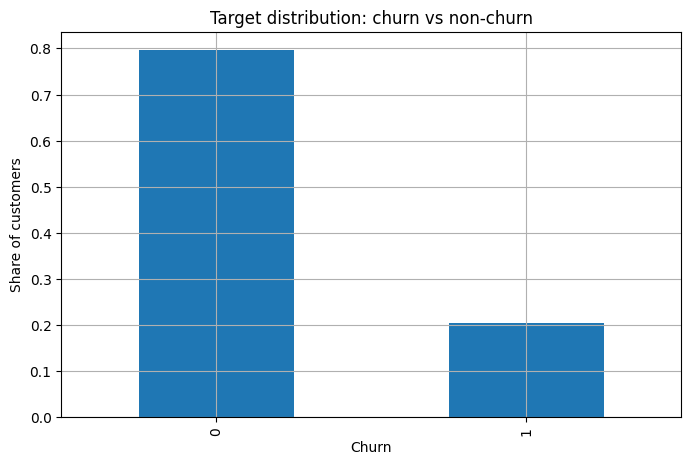

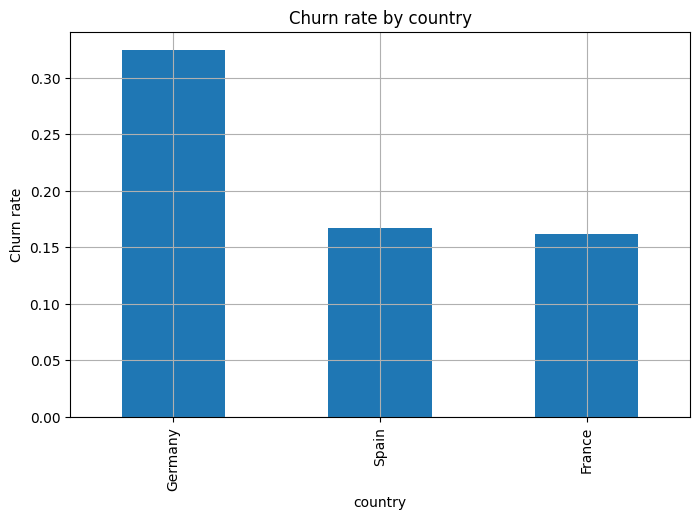

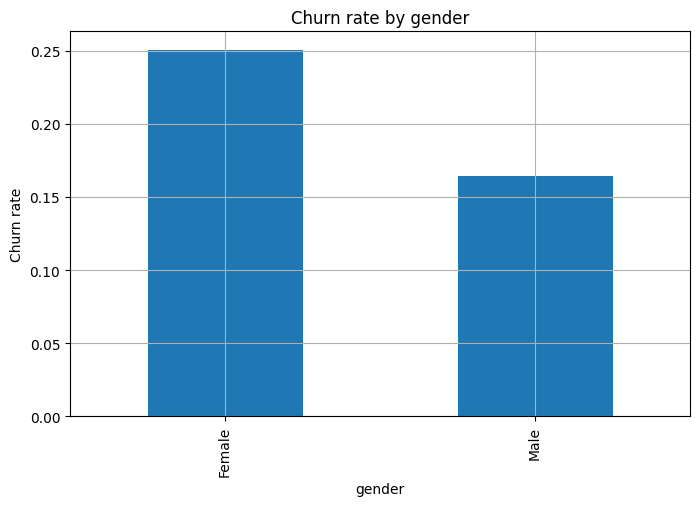

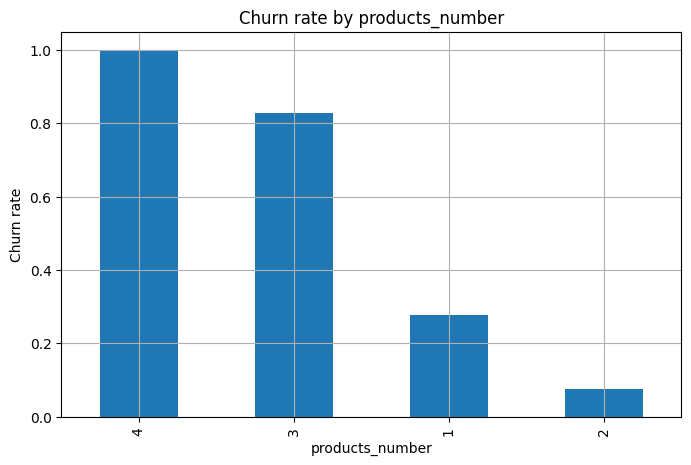

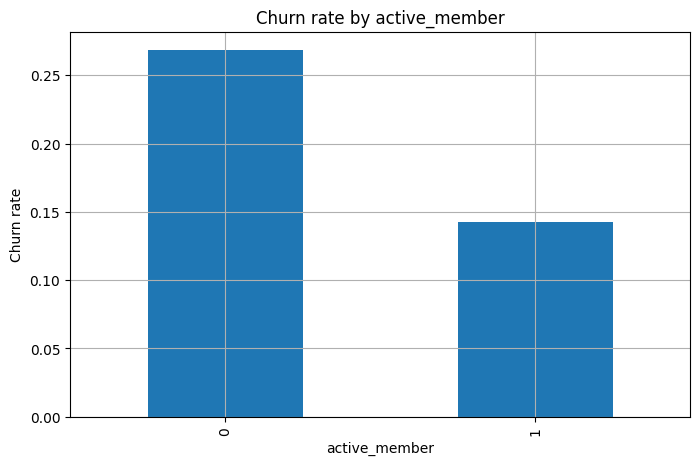

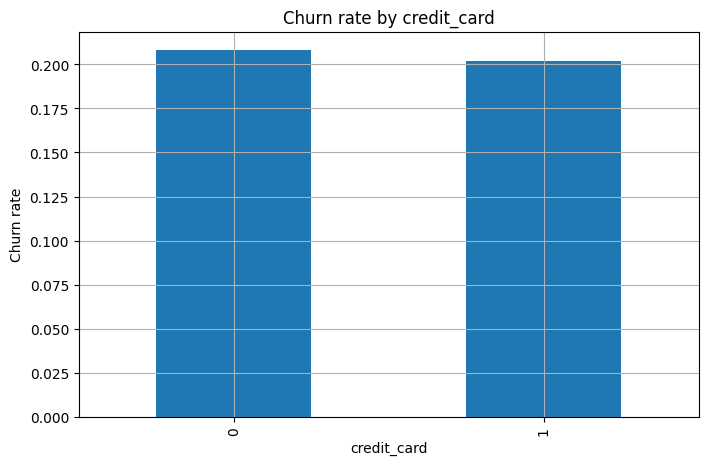

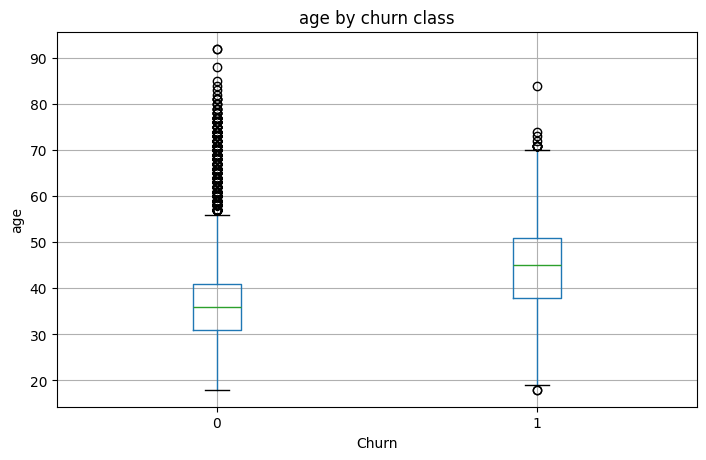

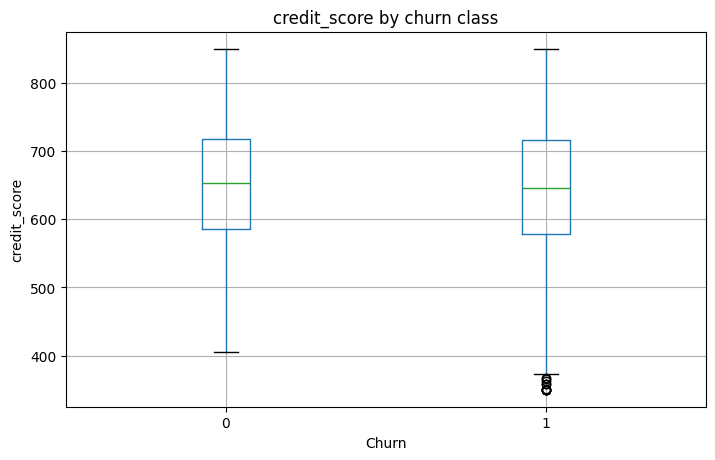

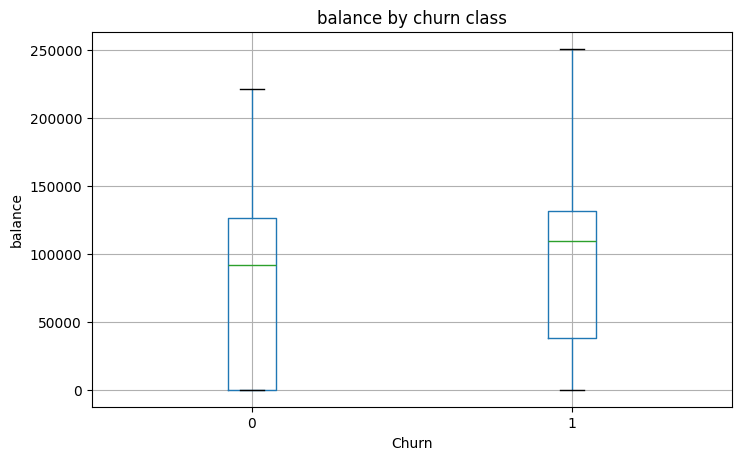

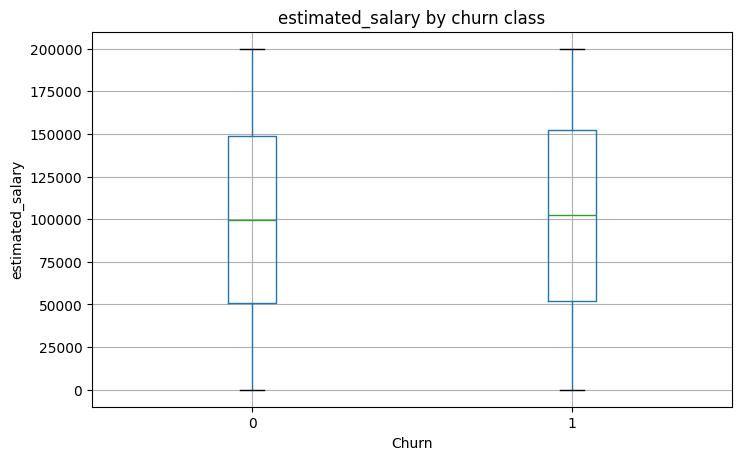

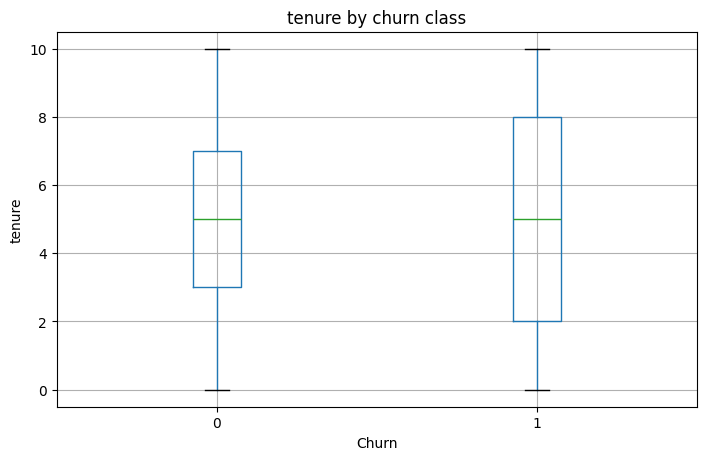

In [4]:
# Quick EDA: churn rate by key business features
fig, ax = plt.subplots()
df['churn'].value_counts(normalize=True).sort_index().plot(kind='bar', ax=ax)
ax.set_title('Target distribution: churn vs non-churn')
ax.set_xlabel('Churn')
ax.set_ylabel('Share of customers')
plt.show()

for col in ['country', 'gender', 'products_number', 'active_member', 'credit_card']:
    churn_rate = df.groupby(col)['churn'].mean().sort_values(ascending=False)
    fig, ax = plt.subplots()
    churn_rate.plot(kind='bar', ax=ax)
    ax.set_title(f'Churn rate by {col}')
    ax.set_ylabel('Churn rate')
    plt.show()

for col in ['age', 'credit_score', 'balance', 'estimated_salary', 'tenure']:
    fig, ax = plt.subplots()
    df.boxplot(column=col, by='churn', ax=ax)
    ax.set_title(f'{col} by churn class')
    ax.set_xlabel('Churn')
    ax.set_ylabel(col)
    plt.suptitle('')
    plt.show()

## EDA Summary

The dataset contains **10,000 customers** and has no missing values. The churn rate is about **20%**, which means the target is imbalanced: most customers stay, but the churn group is large enough to model.

The exploratory analysis supports the business logic of the project:

- churn is not random; it differs by customer segment and behavior;
- customer activity and product usage are important behavioral signals;
- age and balance show visible differences between churned and retained customers;
- the imbalance confirms that accuracy alone would be a weak KPI.

These findings justify a model that can learn nonlinear relationships between demographic, financial, product, and engagement features.


# 3. Modeling Approach

## Why a neural network?

The dataset is tabular and non-sequential. Therefore, RNNs, LSTMs, and Transformers are not the natural first choice because there is no time sequence or text structure. A **deep multilayer perceptron (MLP)** is appropriate because it can model nonlinear interactions between customer attributes.

For example, churn risk may depend not only on age or activity separately, but on combinations such as:

- older inactive customers with high balance,
- customers with many products but low activity,
- customers in specific countries with different balance patterns.

## Proposed architecture

The core model is a deep MLP:

```text
Input customer features
        ↓
Dense(64) + ReLU + Dropout
        ↓
Dense(32) + ReLU + Dropout
        ↓
Dense(16) + ReLU
        ↓
Dense(1) + Sigmoid probability
```

### Design choices

- **Bottleneck structure 64 → 32 → 16:** forces the model to compress customer behavior into a compact representation.
- **Dropout regularization:** reduces overfitting and improves generalization.
- **Weighted binary cross-entropy:** gives higher weight to churn customers because churn is the minority class and false negatives are costly.
- **Threshold optimization:** instead of using the default 0.50 threshold, the model selects a threshold aligned with retention economics and recall requirements.

In [5]:
# Feature definition
TARGET = 'churn'
ID_COL = 'customer_id'

y = df[TARGET].astype(np.float32).values
X = df.drop(columns=[TARGET, ID_COL])

categorical_features = ['country', 'gender']
numerical_features = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']
binary_features = ['credit_card', 'active_member']

# Stratified train/validation/test split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, random_state=SEED, stratify=y_temp
)

print('Train:', X_train.shape, 'Validation:', X_val.shape, 'Test:', X_test.shape)
print('Train churn rate:', y_train.mean().round(4))
print('Validation churn rate:', y_val.mean().round(4))
print('Test churn rate:', y_test.mean().round(4))

Train: (6400, 10) Validation: (1600, 10) Test: (2000, 10)
Train churn rate: 0.2038
Validation churn rate: 0.2038
Test churn rate: 0.2035


In [6]:
# Preprocessing pipeline
# Numeric variables are standardized; categorical variables are one-hot encoded.

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('bin', 'passthrough', binary_features)
    ]
)

X_train_np = preprocessor.fit_transform(X_train).astype(np.float32)
X_val_np = preprocessor.transform(X_val).astype(np.float32)
X_test_np = preprocessor.transform(X_test).astype(np.float32)

try:
    feature_names = preprocessor.get_feature_names_out()
except Exception:
    feature_names = [f'feature_{i}' for i in range(X_train_np.shape[1])]

print('Number of model features after preprocessing:', X_train_np.shape[1])
print(feature_names)

Number of model features after preprocessing: 13
['num__credit_score' 'num__age' 'num__tenure' 'num__balance'
 'num__products_number' 'num__estimated_salary' 'cat__country_France'
 'cat__country_Germany' 'cat__country_Spain' 'cat__gender_Female'
 'cat__gender_Male' 'bin__credit_card' 'bin__active_member']


In [7]:
# PyTorch datasets and loaders

def make_loader(X_np, y_np, batch_size=256, shuffle=False):
    X_tensor = torch.tensor(X_np, dtype=torch.float32)
    y_tensor = torch.tensor(y_np, dtype=torch.float32)
    dataset = TensorDataset(X_tensor, y_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train_np, y_train, shuffle=True)
val_loader = make_loader(X_val_np, y_val, shuffle=False)
test_loader = make_loader(X_test_np, y_test, shuffle=False)

In [8]:
# Neural network architecture

class ChurnMLP(nn.Module):
    def __init__(self, n_features: int, dropout: float = 0.30):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)

model = ChurnMLP(n_features=X_train_np.shape[1], dropout=0.30)
print(model)

# Class imbalance handling: positive class gets higher weight.
pos_weight_value = (len(y_train) - y_train.sum()) / y_train.sum()
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32)
print('Positive class weight:', round(float(pos_weight_value), 3))

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

ChurnMLP(
  (network): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.15, inplace=False)
    (9): Linear(in_features=16, out_features=1, bias=True)
  )
)
Positive class weight: 3.908


In [9]:
# Training loop with early stopping on validation ROC-AUC

def predict_proba_np(model, X_np):
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(X_np, dtype=torch.float32))
        probs = torch.sigmoid(logits).cpu().numpy()
    return probs

def evaluate_auc(model, X_np, y_true):
    probs = predict_proba_np(model, X_np)
    return roc_auc_score(y_true, probs)

EPOCHS = 250
PATIENCE = 25
best_auc = -np.inf
best_state = None
bad_epochs = 0
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    val_probs = predict_proba_np(model, X_val_np)
    val_auc = roc_auc_score(y_val, val_probs)
    val_pr_auc = average_precision_score(y_val, val_probs)
    history.append({
        'epoch': epoch,
        'train_loss': np.mean(train_losses),
        'val_roc_auc': val_auc,
        'val_pr_auc': val_pr_auc
    })

    if val_auc > best_auc:
        best_auc = val_auc
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1

    if epoch % 25 == 0 or epoch == 1:
        print(f'Epoch {epoch:03d} | loss={np.mean(train_losses):.4f} | val ROC-AUC={val_auc:.4f} | val PR-AUC={val_pr_auc:.4f}')

    if bad_epochs >= PATIENCE:
        print(f'Early stopping at epoch {epoch}. Best validation ROC-AUC: {best_auc:.4f}')
        break

model.load_state_dict(best_state)
history_df = pd.DataFrame(history)
display(history_df.tail())

Epoch 001 | loss=1.0994 | val ROC-AUC=0.7008 | val PR-AUC=0.3553
Epoch 025 | loss=0.7723 | val ROC-AUC=0.8517 | val PR-AUC=0.6598
Epoch 050 | loss=0.7408 | val ROC-AUC=0.8546 | val PR-AUC=0.6714
Epoch 075 | loss=0.7133 | val ROC-AUC=0.8558 | val PR-AUC=0.6772
Early stopping at epoch 96. Best validation ROC-AUC: 0.8578


,epoch,train_loss,val_roc_auc,val_pr_auc
91,92,0.704347,0.852944,0.671998
92,93,0.709057,0.854600,0.673710
93,94,0.710843,0.853731,0.670129
94,95,0.708871,0.854670,0.672279
95,96,0.704717,0.854239,0.671872


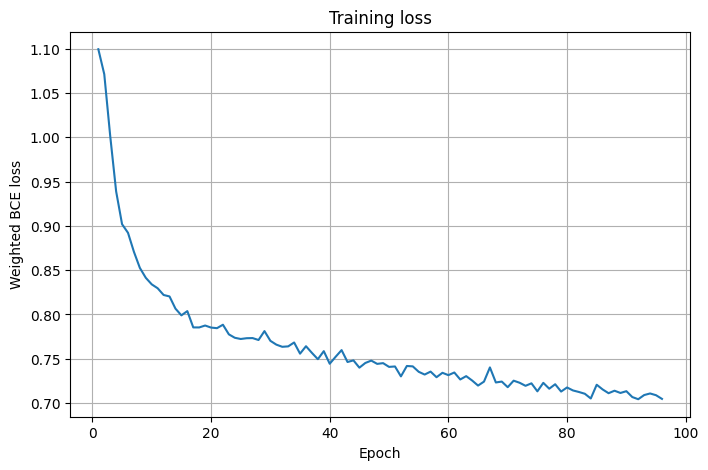

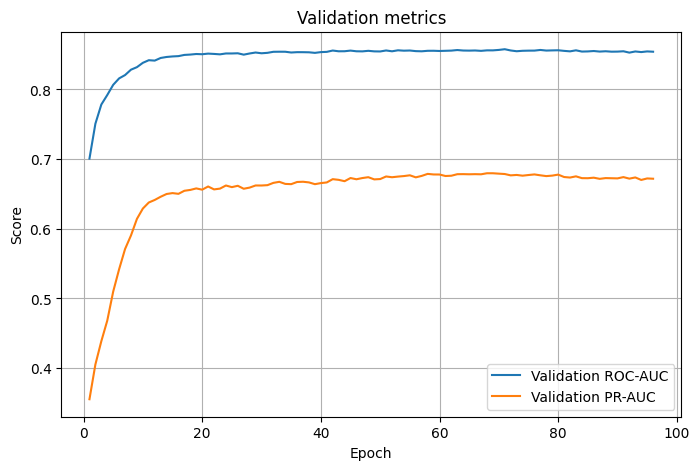

In [10]:
# Training curves
fig, ax = plt.subplots()
ax.plot(history_df['epoch'], history_df['train_loss'])
ax.set_title('Training loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Weighted BCE loss')
plt.show()

fig, ax = plt.subplots()
ax.plot(history_df['epoch'], history_df['val_roc_auc'], label='Validation ROC-AUC')
ax.plot(history_df['epoch'], history_df['val_pr_auc'], label='Validation PR-AUC')
ax.set_title('Validation metrics')
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.legend()
plt.show()

## Training Interpretation

The model was trained with early stopping based on validation ROC-AUC. This is important because neural networks can overfit tabular datasets if they are trained for too long.

The validation ROC-AUC stabilized around **0.858**, while the final test ROC-AUC is **0.8574**. The small gap between validation and test performance suggests that the model generalizes well and is not simply memorizing the training data.

The use of dropout, weighted binary cross-entropy, and early stopping is appropriate for this business problem because the churn class is less frequent and missing churners is costly.


# 4. KPI & Success Criteria

## Primary success metric

The primary model metric is **ROC-AUC**.

This is the right primary metric because the business task is not only to classify customers as churn / no churn. The bank needs a reliable **risk ranking** so that retention teams can prioritize the customers most likely to leave.

A high ROC-AUC means that the neural network usually assigns higher churn scores to customers who actually churn than to customers who stay.

## Supporting metrics

Because churn is an imbalanced problem, accuracy alone is not sufficient. A model can look accurate by predicting that most customers will stay, while still missing many churners. Therefore, we also evaluate:

- **Recall:** the share of actual churners caught by the model. This is critical because missing a high-risk customer means losing a retention opportunity.
- **Precision:** the share of contacted customers who are actual churners. This matters because retention campaigns have a cost.
- **PR-AUC:** useful for imbalanced classification because it focuses on performance for the churn class.
- **F1-score:** a balance between precision and recall.
- **Lift by risk decile:** shows whether the highest-risk customer segments are much riskier than the average customer.

## Business success criterion

The model is successful if it creates a retention list that is both **effective** and **operationally manageable**.

In this notebook, the selected operating point targets about **27.6% of customers** and captures about **71.7% of actual churners** on the test set. This is a strong business trade-off: the bank does not need to contact everyone, but still reaches most customers who are likely to churn.

The threshold is selected on the validation set using business assumptions, not chosen directly on the test set. This keeps the test set as an unbiased final evaluation.


In [11]:
# Predict probabilities
val_probs = predict_proba_np(model, X_val_np)
test_probs = predict_proba_np(model, X_test_np)

print('Validation ROC-AUC:', round(roc_auc_score(y_val, val_probs), 4))
print('Validation PR-AUC:', round(average_precision_score(y_val, val_probs), 4))
print('Test ROC-AUC:', round(roc_auc_score(y_test, test_probs), 4))
print('Test PR-AUC:', round(average_precision_score(y_test, test_probs), 4))

Validation ROC-AUC: 0.8578
Validation PR-AUC: 0.6786
Test ROC-AUC: 0.8574
Test PR-AUC: 0.6975


In [12]:
# Business-aware threshold optimization
# Assumptions can be adjusted with real bank economics.

CUSTOMER_VALUE_SAVED = 500       # expected value if a churner is successfully retained
RETENTION_COST = 50              # cost of contacting / offering retention incentive
RETENTION_SUCCESS_RATE = 0.25    # probability that intervention saves a true churner
MIN_RECALL = 0.70                # business requirement: catch at least 70% of churners on validation

def threshold_table(y_true, probs):
    rows = []
    for threshold in np.linspace(0.05, 0.95, 181):
        preds = (probs >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        expected_profit = (
            tp * RETENTION_SUCCESS_RATE * CUSTOMER_VALUE_SAVED
            - (tp + fp) * RETENTION_COST
        )
        contact_rate = (tp + fp) / len(y_true)
        rows.append({
            'threshold': threshold,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
            'contact_rate': contact_rate,
            'expected_profit': expected_profit
        })
    return pd.DataFrame(rows)

val_thresholds = threshold_table(y_val, val_probs)
feasible = val_thresholds[val_thresholds['recall'] >= MIN_RECALL].copy()

if len(feasible) == 0:
    best_threshold_row = val_thresholds.sort_values('expected_profit', ascending=False).iloc[0]
else:
    best_threshold_row = feasible.sort_values('expected_profit', ascending=False).iloc[0]

best_threshold = float(best_threshold_row['threshold'])
print('Selected threshold:', round(best_threshold, 3))
display(best_threshold_row.to_frame('validation_value'))

Selected threshold: 0.57


,validation_value
threshold,0.570000
precision,0.526437
recall,0.702454
f1,0.601840
tp,229.000000
fp,206.000000
fn,97.000000
tn,1068.000000
contact_rate,0.271875
expected_profit,6875.000000


In [13]:
# Test-set evaluation using the selected threshold
test_pred = (test_probs >= best_threshold).astype(int)

metrics = {
    'ROC-AUC': roc_auc_score(y_test, test_probs),
    'PR-AUC': average_precision_score(y_test, test_probs),
    'Precision': precision_score(y_test, test_pred, zero_division=0),
    'Recall': recall_score(y_test, test_pred, zero_division=0),
    'F1': f1_score(y_test, test_pred, zero_division=0),
    'Contact rate': test_pred.mean()
}
metrics_df = pd.DataFrame(metrics, index=['test']).T.rename(columns={'test': 'value'})
display(metrics_df.style.format({'value': '{:.4f}'}))

print(classification_report(y_test, test_pred, target_names=['Stayed', 'Churned'], zero_division=0))

cm = confusion_matrix(y_test, test_pred)
cm_df = pd.DataFrame(cm, index=['Actual stayed', 'Actual churned'], columns=['Predicted stayed', 'Predicted churned'])
display(cm_df)

,value
ROC-AUC,0.8574
PR-AUC,0.6975
Precision,0.5290
Recall,0.7174
F1,0.6090
Contact rate,0.2760


              precision    recall  f1-score   support

      Stayed       0.92      0.84      0.88      1593
     Churned       0.53      0.72      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000



,Predicted stayed,Predicted churned
Actual stayed,1333,260
Actual churned,115,292


## Test Performance Interpretation

The final model performance is strong for a customer churn problem.

The model reaches **ROC-AUC = 0.8574**, meaning it produces a reliable ranking of customers by churn risk. This is more important than raw accuracy because retention teams usually act on a ranked list of customers.

At the selected threshold, the model achieves:

- **Recall = 0.7174:** it identifies about 72% of actual churners.
- **Precision = 0.5290:** about 53% of contacted customers are true churners.
- **Contact rate = 0.2760:** only about 28% of customers need immediate action.

This is a good operational trade-off. The model avoids contacting everyone while still capturing most churners.


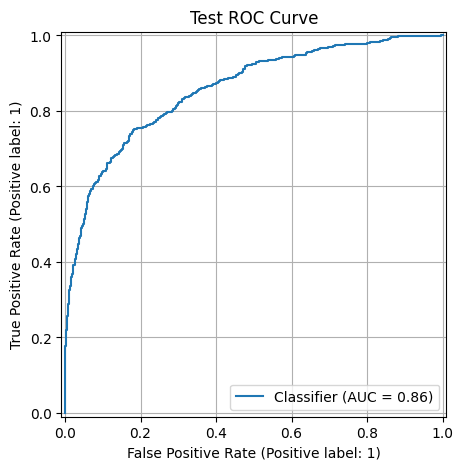

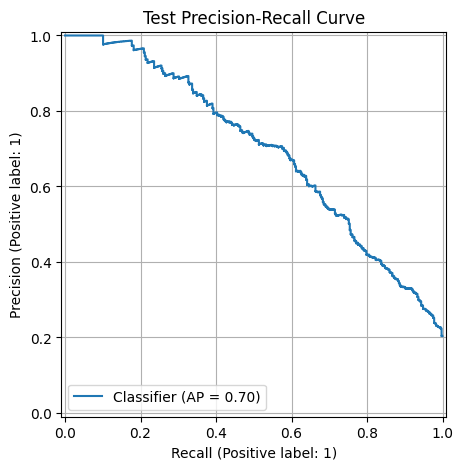

In [14]:
# ROC and Precision-Recall curves
fig, ax = plt.subplots()
RocCurveDisplay.from_predictions(y_test, test_probs, ax=ax)
ax.set_title('Test ROC Curve')
plt.show()

fig, ax = plt.subplots()
PrecisionRecallDisplay.from_predictions(y_test, test_probs, ax=ax)
ax.set_title('Test Precision-Recall Curve')
plt.show()

,customers,churners,churn_rate,avg_score,lift_vs_average
risk_decile,,,,,
1,200,160,80.00%,0.927,3.93x
2,200,95,47.50%,0.727,2.33x
3,200,51,25.50%,0.596,1.25x
4,200,25,12.50%,0.479,0.61x
5,200,25,12.50%,0.360,0.61x
6,200,23,11.50%,0.267,0.57x
7,200,7,3.50%,0.185,0.17x
8,200,12,6.00%,0.123,0.29x
9,200,7,3.50%,0.076,0.17x


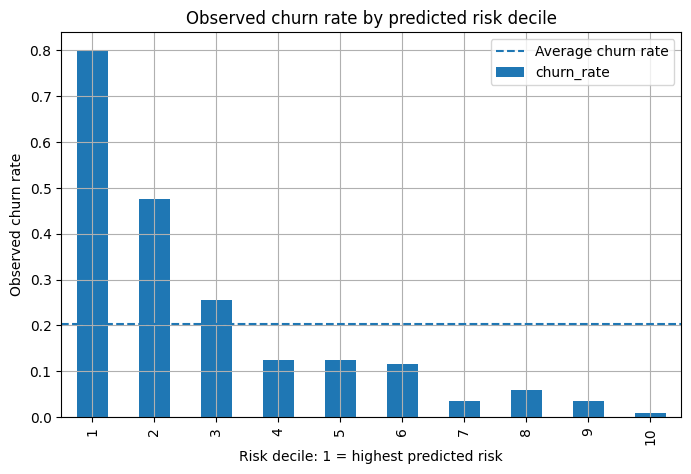

In [15]:
# Lift analysis: how concentrated are churners in the highest-risk groups?
test_results = X_test.copy()
test_results['actual_churn'] = y_test.astype(int)
test_results['predicted_churn_probability'] = test_probs
test_results['risk_decile'] = pd.qcut(
    test_results['predicted_churn_probability'],
    q=10, labels=False, duplicates='drop'
) + 1
# 10 = highest risk
test_results['risk_decile'] = 11 - test_results['risk_decile']

decile_summary = (
    test_results.groupby('risk_decile')
    .agg(
        customers=('actual_churn', 'size'),
        churners=('actual_churn', 'sum'),
        churn_rate=('actual_churn', 'mean'),
        avg_score=('predicted_churn_probability', 'mean')
    )
    .sort_index()
)
decile_summary['lift_vs_average'] = decile_summary['churn_rate'] / test_results['actual_churn'].mean()
display(decile_summary.style.format({
    'churn_rate': '{:.2%}',
    'avg_score': '{:.3f}',
    'lift_vs_average': '{:.2f}x'
}))

fig, ax = plt.subplots()
decile_summary['churn_rate'].plot(kind='bar', ax=ax)
ax.axhline(test_results['actual_churn'].mean(), linestyle='--', label='Average churn rate')
ax.set_title('Observed churn rate by predicted risk decile')
ax.set_xlabel('Risk decile: 1 = highest predicted risk')
ax.set_ylabel('Observed churn rate')
ax.legend()
plt.show()

## Lift Analysis Interpretation

The lift table is one of the strongest business results in the notebook.

The highest-risk decile contains **200 customers**, of whom **160 actually churned**. This is an **80.0% churn rate**, compared with the average test churn rate of about **20.35%**.

That means the top decile has approximately **3.93x lift** over the average customer. In business terms, the model successfully concentrates churn risk at the top of the ranked list.

This supports a practical retention strategy:

- top 10%: high-priority personalized retention actions;
- next 10–20%: lighter offers or proactive communication;
- lower-risk groups: monitoring without costly intervention.


# 5. Interpretability

Neural networks are often criticized as black boxes. For a churn project, interpretability is important because business teams need to understand why customers are flagged as high risk and how the model can be used in a retention workflow.

This notebook uses two practical interpretability methods:

1. **Permutation importance:** measures how much ROC-AUC decreases when one original business feature is randomly shuffled.
2. **Customer-level risk profiles:** shows the actual characteristics of the highest-risk customers selected by the model.

Permutation importance is model-agnostic and appropriate for neural networks because it evaluates feature contribution through prediction behavior rather than through linear coefficients.

In this project, interpretation is performed on the original business features before preprocessing. This makes the results easier to explain to non-technical stakeholders: for example, `products_number`, `age`, `active_member`, and `balance` are more meaningful than one-hot encoded technical columns.


Baseline ROC-AUC: 0.8574


,feature,importance_mean,importance_std
0,products_number,0.1435,0.0084
1,age,0.1087,0.0113
2,active_member,0.0260,0.0055
3,balance,0.0257,0.0038
4,country,0.0190,0.0024
5,gender,0.0103,0.0023
6,credit_score,0.0007,0.0006
7,tenure,0.0003,0.0014
8,estimated_salary,-0.0007,0.0016
9,credit_card,-0.0009,0.0006


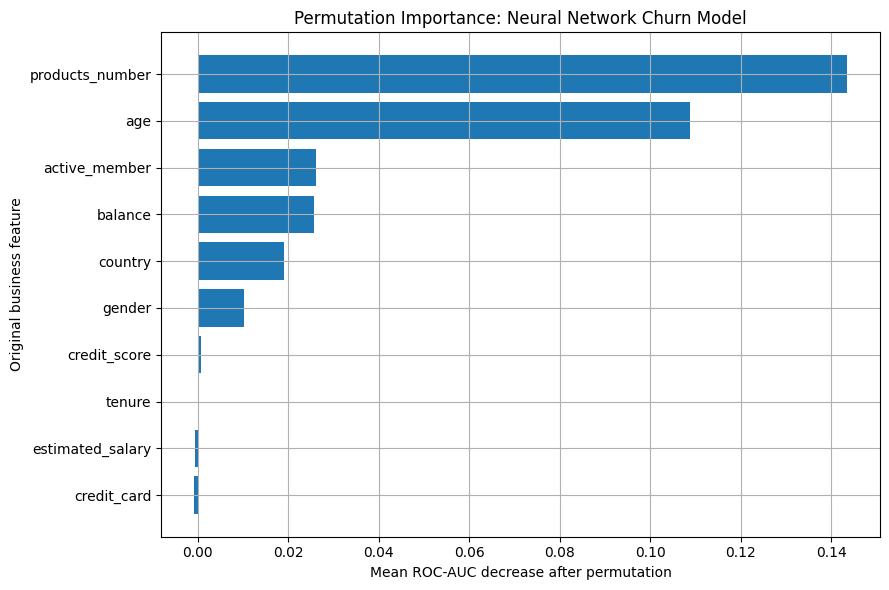

In [16]:
# Permutation importance for PyTorch neural network
# This version works with raw X_test that contains both numerical and categorical features.
# It permutes original business features, then applies the fitted preprocessor before prediction.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import roc_auc_score

# Make sure device exists
try:
    device
except NameError:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()


def predict_proba_from_raw(model, preprocessor, X_raw, device=device):
    """
    Takes raw customer features, applies the fitted preprocessing pipeline,
    and returns churn probabilities from the trained PyTorch model.
    """
    X_processed = preprocessor.transform(X_raw).astype(np.float32)

    X_tensor = torch.tensor(X_processed, dtype=torch.float32).to(device)

    with torch.no_grad():
        probs = model(X_tensor).cpu().numpy().reshape(-1)

    return probs


def manual_permutation_importance_raw(
    model,
    preprocessor,
    X_raw,
    y_true,
    n_repeats=10,
    random_state=42,
    device=device
):
    """
    Calculates permutation importance on original raw features.

    For each original feature:
    1. Shuffle its values.
    2. Apply the same preprocessing pipeline used during training.
    3. Get predictions from the neural network.
    4. Measure the ROC-AUC drop.

    Larger ROC-AUC decrease = more important feature.
    """
    rng = np.random.default_rng(random_state)

    X_base = X_raw.copy().reset_index(drop=True)
    y_array = np.array(y_true)

    baseline_probs = predict_proba_from_raw(
        model=model,
        preprocessor=preprocessor,
        X_raw=X_base,
        device=device
    )

    baseline_auc = roc_auc_score(y_array, baseline_probs)

    results = []

    for feature in X_base.columns:
        auc_drops = []

        for _ in range(n_repeats):
            X_perm = X_base.copy()
            X_perm[feature] = rng.permutation(X_perm[feature].values)

            perm_probs = predict_proba_from_raw(
                model=model,
                preprocessor=preprocessor,
                X_raw=X_perm,
                device=device
            )

            perm_auc = roc_auc_score(y_array, perm_probs)
            auc_drops.append(baseline_auc - perm_auc)

        results.append({
            "feature": feature,
            "importance_mean": np.mean(auc_drops),
            "importance_std": np.std(auc_drops)
        })

    importance_df = (
        pd.DataFrame(results)
        .sort_values("importance_mean", ascending=False)
        .reset_index(drop=True)
    )

    return importance_df, baseline_auc


importance_df, baseline_auc = manual_permutation_importance_raw(
    model=model,
    preprocessor=preprocessor,
    X_raw=X_test,
    y_true=y_test,
    n_repeats=10,
    random_state=SEED if "SEED" in globals() else 42,
    device=device
)

print(f"Baseline ROC-AUC: {baseline_auc:.4f}")

display(
    importance_df.style.format({
        "importance_mean": "{:.4f}",
        "importance_std": "{:.4f}"
    })
)

plt.figure(figsize=(9, 6))
plot_df = importance_df.sort_values("importance_mean")

plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.xlabel("Mean ROC-AUC decrease after permutation")
plt.ylabel("Original business feature")
plt.title("Permutation Importance: Neural Network Churn Model")
plt.tight_layout()
plt.show()

## Feature Importance Interpretation

Permutation importance shows that the neural network relies most on:

1. **products_number**
2. **age**
3. **active_member**
4. **balance**
5. **country**

This is consistent with banking churn logic. Product relationship depth, customer age, engagement status, and financial relationship size are plausible churn drivers.

Features such as `estimated_salary`, `credit_card`, and `tenure` have very low importance in this trained model. This does not mean they are useless in every bank, but in this dataset they do not materially improve ROC-AUC.

This interpretation makes the neural network more useful for business stakeholders because it identifies which customer attributes should be monitored in retention dashboards.


# 5.1. Explainable AI (XAI) Extension: SHAP, LIME and SOM

The project now includes an additional Explainable AI layer. This is important because a churn model is not only a predictive system, but also a decision-support tool for retention teams.

In a banking context, explainability is necessary for three reasons:

1. **Trust:** business users need to understand why the neural network assigns high churn risk.
2. **Actionability:** retention teams need to know which customer factors may be driving churn risk.
3. **Model governance:** financial institutions should be able to check whether a model relies on reasonable signals rather than technical artifacts or spurious correlations.

We use three complementary XAI methods:

| Method | Role in this project | Explanation type |
|---|---|---|
| **Permutation Importance** | Measures how much model quality drops when one original feature is shuffled | Global, model-agnostic |
| **SHAP** | Estimates feature contributions to neural-network predictions | Global and local |
| **LIME** | Explains one selected customer prediction using a local surrogate model | Local, model-agnostic |
| **SOM** | Visualizes customer structure in neural-network latent space | Global representation analysis |

Together, these methods make the MLP model more transparent: permutation importance and SHAP show which features matter overall, LIME explains individual high-risk customers, and SOM shows whether the neural network organizes customers into meaningful risk regions.

In [17]:
# XAI setup utilities
# These helper functions reuse the trained PyTorch MLP and the fitted preprocessing pipeline.

import sys
import subprocess
import importlib
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# Ensure the model is on the right device.
try:
    device
except NameError:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()


def install_if_missing(package_name, import_name=None):
    """
    Imports a package if available. If it is missing, installs it quietly.
    This makes the notebook more portable in Google Colab.
    """
    if import_name is None:
        import_name = package_name
    try:
        return importlib.import_module(import_name)
    except ImportError:
        print(f'Installing {package_name}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package_name])
        return importlib.import_module(import_name)


def clean_feature_name(name):
    """
    Converts ColumnTransformer names into readable names.
    Example: num__age -> age, cat__country_France -> country_France.
    """
    return str(name).replace('num__', '').replace('cat__', '').replace('bin__', '')

processed_feature_names = [clean_feature_name(f) for f in feature_names]

X_train_processed_df = pd.DataFrame(X_train_np, columns=processed_feature_names, index=X_train.index)
X_val_processed_df = pd.DataFrame(X_val_np, columns=processed_feature_names, index=X_val.index)
X_test_processed_df = pd.DataFrame(X_test_np, columns=processed_feature_names, index=X_test.index)


def predict_proba_processed(model, X_processed, device=device):
    """
    Predicts churn probabilities from already preprocessed numeric model features.
    """
    model.eval()
    X_array = X_processed.values if hasattr(X_processed, 'values') else X_processed
    X_tensor = torch.tensor(X_array, dtype=torch.float32).to(device)
    with torch.no_grad():
        logits = model(X_tensor)
        probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)
    return probs


def predict_proba_raw(model, preprocessor, X_raw, device=device):
    """
    Predicts churn probabilities from original raw business features.
    """
    X_processed = preprocessor.transform(X_raw).astype(np.float32)
    return predict_proba_processed(model, X_processed, device=device)


def predict_proba_2class_processed(X_processed):
    """
    Prediction function required by LIME.
    Returns probabilities for both classes: [retained, churn].
    """
    churn_probs = predict_proba_processed(model, X_processed, device=device)
    return np.column_stack([1 - churn_probs, churn_probs])

print('XAI utilities are ready.')
print('Processed feature count:', len(processed_feature_names))
print('Example processed features:', processed_feature_names[:10])

XAI utilities are ready.
Processed feature count: 13
Example processed features: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary', 'country_France', 'country_Germany', 'country_Spain', 'gender_Female']


## 5.2. SHAP: Global and Local Feature Contributions

**SHAP** explains how each feature contributes to the neural network output relative to a baseline prediction. For this MLP model, SHAP is useful because it gives both:

- **global explanations:** which features matter most on average;
- **local explanations:** which features pushed one specific customer toward higher or lower churn risk.

In this notebook, SHAP is applied to the processed feature space used by the neural network. For business readability, one-hot encoded country and gender features are also aggregated back into original business-level feature groups.

Top processed features by mean absolute SHAP value:


,processed_feature,mean_abs_shap
0,products_number,0.83062
1,age,0.68469
2,active_member,0.28821
3,balance,0.24511
4,gender_Male,0.22141
5,country_France,0.17126
6,country_Germany,0.15039
7,country_Spain,0.12224
8,gender_Female,0.10123
9,tenure,0.07698


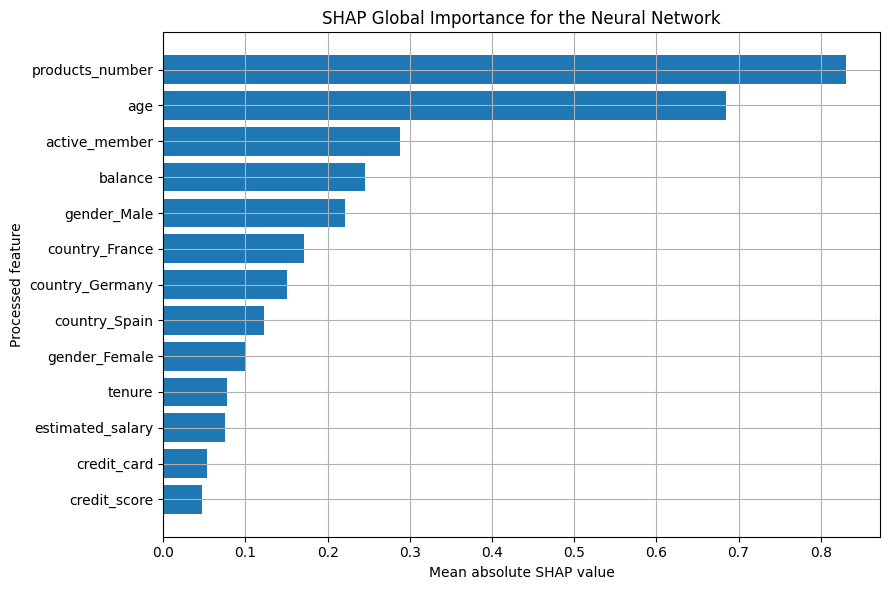

In [18]:
# SHAP explanation for the trained PyTorch MLP
# We explain the neural network on a sample to keep runtime reasonable in Colab.

shap = install_if_missing('shap')

RNG = np.random.default_rng(SEED if 'SEED' in globals() else 42)

background_size = min(200, X_train_np.shape[0])
explain_size = min(300, X_test_np.shape[0])

background_idx = RNG.choice(X_train_np.shape[0], size=background_size, replace=False)
explain_idx = RNG.choice(X_test_np.shape[0], size=explain_size, replace=False)

X_background = X_train_np[background_idx].astype(np.float32)
X_explain = X_test_np[explain_idx].astype(np.float32)
y_explain = np.array(y_test)[explain_idx]
probs_explain = test_probs[explain_idx]

class ChurnLogitWrapper(torch.nn.Module):
    """
    SHAP expects model outputs in a 2D format: [n_samples, n_outputs].
    The base model returns logits for the churn class, so we reshape to [n_samples, 1].
    """
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, x):
        return self.base_model(x).view(-1, 1)

shap_model = ChurnLogitWrapper(model).to(device)
shap_model.eval()

background_tensor = torch.tensor(X_background, dtype=torch.float32).to(device)
explain_tensor = torch.tensor(X_explain, dtype=torch.float32).to(device)

try:
    explainer = shap.DeepExplainer(shap_model, background_tensor)
    shap_values_raw = explainer.shap_values(explain_tensor)

    if isinstance(shap_values_raw, list):
        shap_values = shap_values_raw[0]
    else:
        shap_values = shap_values_raw

    if hasattr(shap_values, 'detach'):
        shap_values = shap_values.detach().cpu().numpy()

    shap_values = np.array(shap_values)
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 0]

except Exception as e:
    print('DeepExplainer failed, falling back to model-agnostic KernelExplainer.')
    print('Reason:', repr(e))

    kernel_background = shap.sample(X_train_np, min(80, X_train_np.shape[0]), random_state=SEED if 'SEED' in globals() else 42)
    kernel_explain = X_explain[:min(120, X_explain.shape[0])]
    explainer = shap.KernelExplainer(lambda z: predict_proba_processed(model, z, device=device), kernel_background)
    shap_values = explainer.shap_values(kernel_explain, nsamples=100)
    X_explain = kernel_explain
    y_explain = y_explain[:len(kernel_explain)]
    probs_explain = probs_explain[:len(kernel_explain)]

shap_values = np.asarray(shap_values, dtype=float)
X_explain_df = pd.DataFrame(X_explain, columns=processed_feature_names)

shap_importance = (
    pd.DataFrame({
        'processed_feature': processed_feature_names,
        'mean_abs_shap': np.abs(shap_values).mean(axis=0)
    })
    .sort_values('mean_abs_shap', ascending=False)
    .reset_index(drop=True)
)

print('Top processed features by mean absolute SHAP value:')
display(shap_importance.head(15).style.format({'mean_abs_shap': '{:.5f}'}))

plt.figure(figsize=(9, 6))
plot_df = shap_importance.head(15).sort_values('mean_abs_shap')
plt.barh(plot_df['processed_feature'], plot_df['mean_abs_shap'])
plt.xlabel('Mean absolute SHAP value')
plt.ylabel('Processed feature')
plt.title('SHAP Global Importance for the Neural Network')
plt.tight_layout()
plt.show()

Business-level SHAP importance:


,business_feature,mean_abs_shap_grouped
0,products_number,0.83062
1,age,0.68469
2,country,0.44390
3,gender,0.32264
4,active_member,0.28821
5,balance,0.24511
6,tenure,0.07698
7,estimated_salary,0.07480
8,credit_card,0.05311
9,credit_score,0.04692


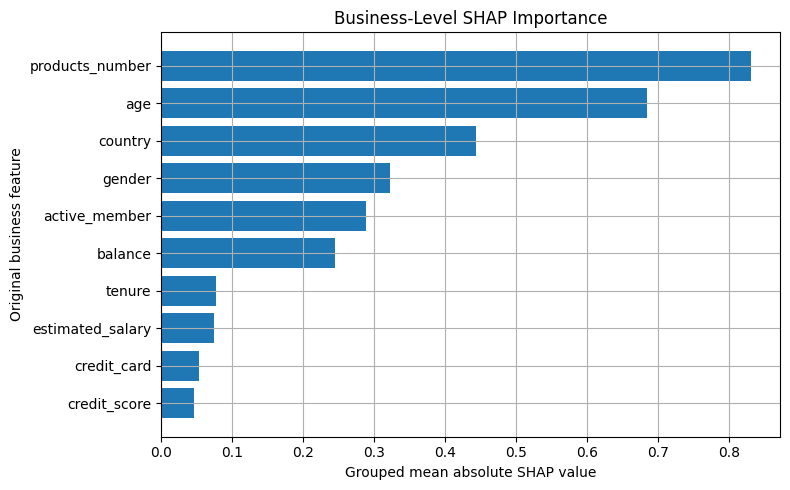

In [19]:
# Aggregate SHAP importances from processed features back to original business feature groups.

original_feature_groups = {
    'credit_score': ['credit_score'],
    'age': ['age'],
    'tenure': ['tenure'],
    'balance': ['balance'],
    'products_number': ['products_number'],
    'estimated_salary': ['estimated_salary'],
    'credit_card': ['credit_card'],
    'active_member': ['active_member'],
    'country': [f for f in processed_feature_names if f.startswith('country_')],
    'gender': [f for f in processed_feature_names if f.startswith('gender_')]
}

business_shap_rows = []
for group, group_features in original_feature_groups.items():
    existing = [f for f in group_features if f in processed_feature_names]
    if len(existing) == 0:
        continue
    idx = [processed_feature_names.index(f) for f in existing]
    business_shap_rows.append({
        'business_feature': group,
        'mean_abs_shap_grouped': np.abs(shap_values[:, idx]).sum(axis=1).mean()
    })

business_shap = (
    pd.DataFrame(business_shap_rows)
    .sort_values('mean_abs_shap_grouped', ascending=False)
    .reset_index(drop=True)
)

print('Business-level SHAP importance:')
display(business_shap.style.format({'mean_abs_shap_grouped': '{:.5f}'}))

plt.figure(figsize=(8, 5))
plot_df = business_shap.sort_values('mean_abs_shap_grouped')
plt.barh(plot_df['business_feature'], plot_df['mean_abs_shap_grouped'])
plt.xlabel('Grouped mean absolute SHAP value')
plt.ylabel('Original business feature')
plt.title('Business-Level SHAP Importance')
plt.tight_layout()
plt.show()

Local SHAP explanation for one high-risk customer
Predicted churn probability: 1.000
Actual churn label: 1


,feature,feature_value_processed,shap_contribution,abs_contribution
0,products_number,4.233,9.42484,9.42484
1,age,1.809,2.36322,2.36322
2,balance,0.913,0.58123,0.58123
3,active_member,0.000,0.41497,0.41497
4,country_Germany,1.000,-0.39418,0.39418
5,country_France,0.000,0.34429,0.34429
6,gender_Male,1.000,-0.29486,0.29486
7,credit_score,0.896,-0.27335,0.27335
8,gender_Female,0.000,0.24808,0.24808
9,estimated_salary,-1.244,-0.23389,0.23389


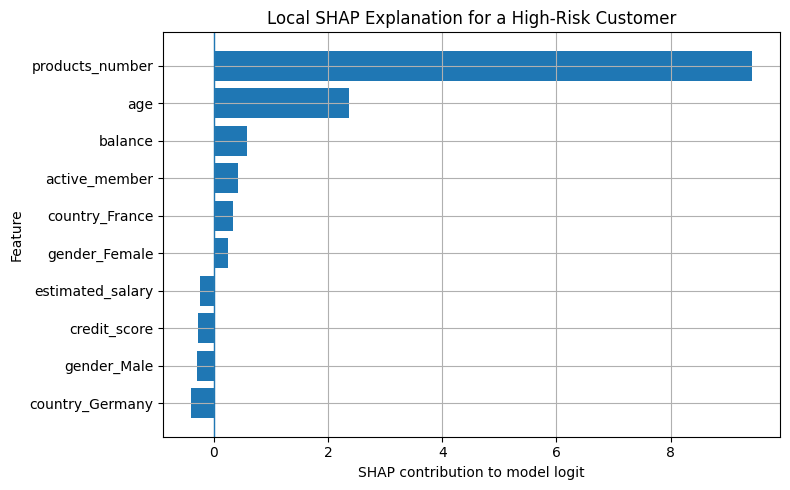

In [20]:
# SHAP local explanation for the highest-risk customer in the explained sample.

local_idx = int(np.argmax(probs_explain))
local_probability = float(probs_explain[local_idx])
local_actual = int(y_explain[local_idx])

local_shap = pd.DataFrame({
    'feature': processed_feature_names,
    'feature_value_processed': X_explain[local_idx],
    'shap_contribution': shap_values[local_idx]
})
local_shap['abs_contribution'] = local_shap['shap_contribution'].abs()
local_shap = local_shap.sort_values('abs_contribution', ascending=False).reset_index(drop=True)

print('Local SHAP explanation for one high-risk customer')
print(f'Predicted churn probability: {local_probability:.3f}')
print(f'Actual churn label: {local_actual}')
display(local_shap.head(12).style.format({
    'feature_value_processed': '{:.3f}',
    'shap_contribution': '{:.5f}',
    'abs_contribution': '{:.5f}'
}))

plt.figure(figsize=(8, 5))
plot_df = local_shap.head(10).sort_values('shap_contribution')
plt.barh(plot_df['feature'], plot_df['shap_contribution'])
plt.axvline(0, linewidth=1)
plt.xlabel('SHAP contribution to model logit')
plt.ylabel('Feature')
plt.title('Local SHAP Explanation for a High-Risk Customer')
plt.tight_layout()
plt.show()

### SHAP Interpretation

SHAP provides a stronger explanation layer than simple feature importance because it estimates how each feature contributes to the neural network output.

For this churn model, SHAP should be interpreted as follows:

- Features with larger mean absolute SHAP values have stronger average influence on the model's churn-risk score.
- Positive local SHAP values push a customer toward a higher churn-risk prediction.
- Negative local SHAP values push a customer toward a lower churn-risk prediction.

From a business perspective, SHAP helps validate whether the neural network uses reasonable churn signals such as product usage, age, activity status, balance, and geography. It also gives retention teams a more actionable explanation for individual high-risk customers instead of only a probability score.

## 5.3. LIME: Local Explanation for One Customer

**LIME** explains an individual prediction by creating many small perturbations around one customer and fitting a simple local surrogate model. Unlike SHAP, LIME does not need access to the internals of the neural network. It only needs a prediction function.

In this project, LIME is used as a local sanity check: for one high-risk customer, it shows which feature conditions increase or decrease the predicted churn probability.

Installing lime...
LIME explanation for the highest-risk test customer
Predicted churn probability: 1.000
Actual churn label: 1


,local_rule,contribution_to_churn
0,products_number > 0.80,0.60910
1,age > 0.48,0.33375
2,active_member <= 0.00,0.13704
3,0.00 < gender_Male <= 1.00,-0.08039
4,balance > 0.82,0.07668
5,country_France <= 0.00,0.05046
6,0.00 < country_Germany <= 1.00,0.04917
7,country_Spain <= 0.00,0.03524
8,gender_Female <= 0.00,-0.02795
9,tenure <= -0.78,0.02786


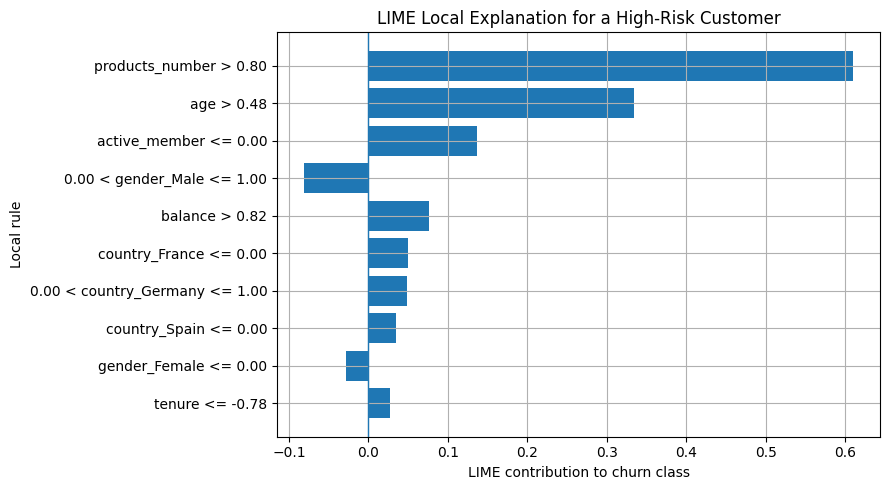

In [21]:
# LIME explanation for a high-risk customer

lime_module = install_if_missing('lime', 'lime')
from lime.lime_tabular import LimeTabularExplainer

high_risk_idx = int(np.argmax(test_probs))
high_risk_customer_processed = X_test_np[high_risk_idx]
high_risk_probability = float(test_probs[high_risk_idx])
high_risk_actual = int(y_test[high_risk_idx])

lime_explainer = LimeTabularExplainer(
    training_data=X_train_np,
    feature_names=processed_feature_names,
    class_names=['Retained', 'Churn'],
    mode='classification',
    discretize_continuous=True,
    random_state=SEED if 'SEED' in globals() else 42
)

lime_exp = lime_explainer.explain_instance(
    data_row=high_risk_customer_processed,
    predict_fn=predict_proba_2class_processed,
    num_features=10,
    labels=[1]
)

lime_df = pd.DataFrame(lime_exp.as_list(label=1), columns=['local_rule', 'contribution_to_churn'])

print('LIME explanation for the highest-risk test customer')
print(f'Predicted churn probability: {high_risk_probability:.3f}')
print(f'Actual churn label: {high_risk_actual}')
display(lime_df.style.format({'contribution_to_churn': '{:.5f}'}))

plt.figure(figsize=(9, 5))
plot_df = lime_df.iloc[::-1]
plt.barh(plot_df['local_rule'], plot_df['contribution_to_churn'])
plt.axvline(0, linewidth=1)
plt.xlabel('LIME contribution to churn class')
plt.ylabel('Local rule')
plt.title('LIME Local Explanation for a High-Risk Customer')
plt.tight_layout()
plt.show()

### LIME Interpretation

LIME complements SHAP by focusing on one specific customer rather than the full dataset.

This is useful for an operational retention workflow. A retention manager could open a high-risk customer record and see not only the predicted churn probability, but also the local factors that pushed the neural network toward the churn class.

However, LIME should be interpreted as a **local approximation**, not as the full global logic of the neural network. It is best used for individual case review and sanity checks, while SHAP and permutation importance are better for global model understanding.

## 5.4. SOM: Visualizing Customer Structure in Neural Network Latent Space

A **Self-Organizing Map (SOM)** is an unsupervised neural network that projects high-dimensional data onto a two-dimensional grid while preserving neighborhood relationships.

In this project, SOM is used to understand the structure learned by the MLP. We compare two views:

1. **Processed input space:** standardized and encoded customer features before the neural network.
2. **Latent neural-network space:** the 16-dimensional representation learned by the last hidden layer of the MLP.

If the latent-space SOM shows clearer risk regions than the raw input-space SOM, it means the neural network has learned a more useful representation for separating churn-risk customers.

Installing minisom...


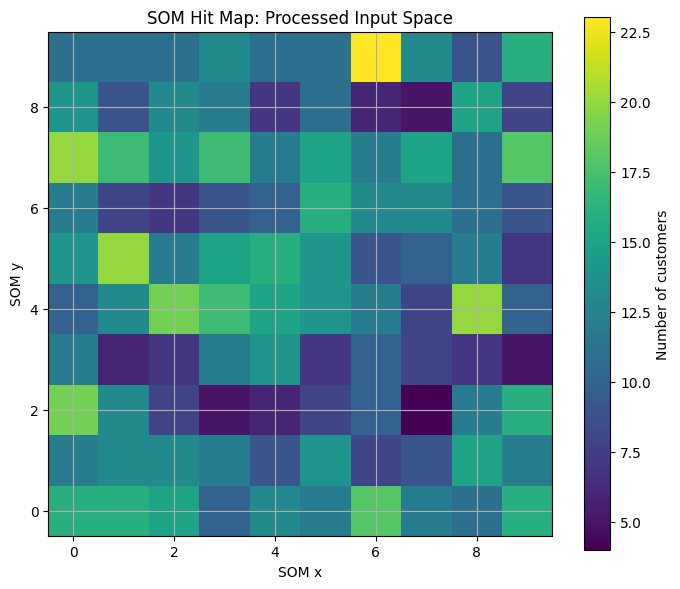

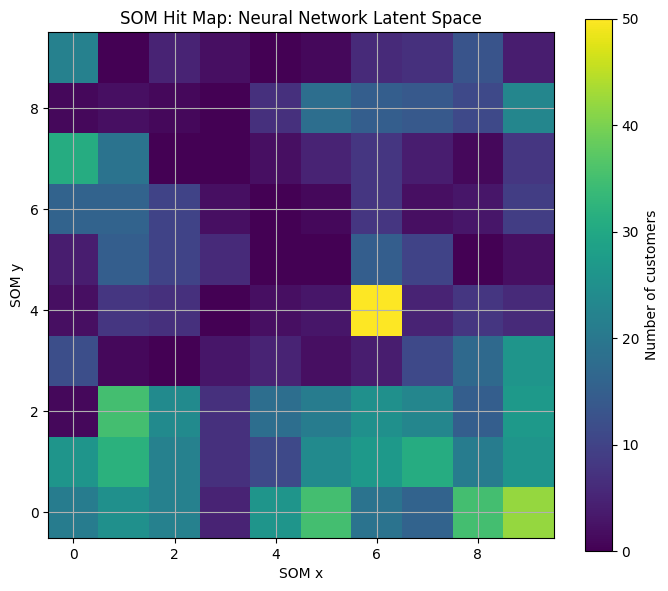

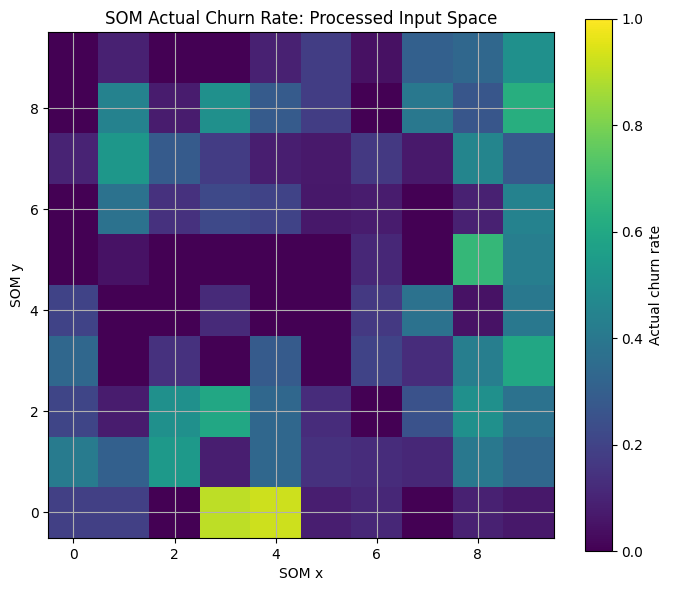

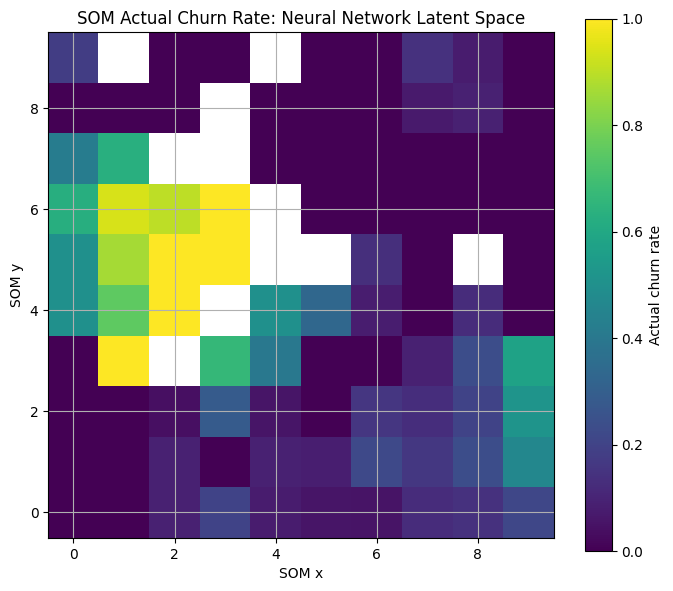

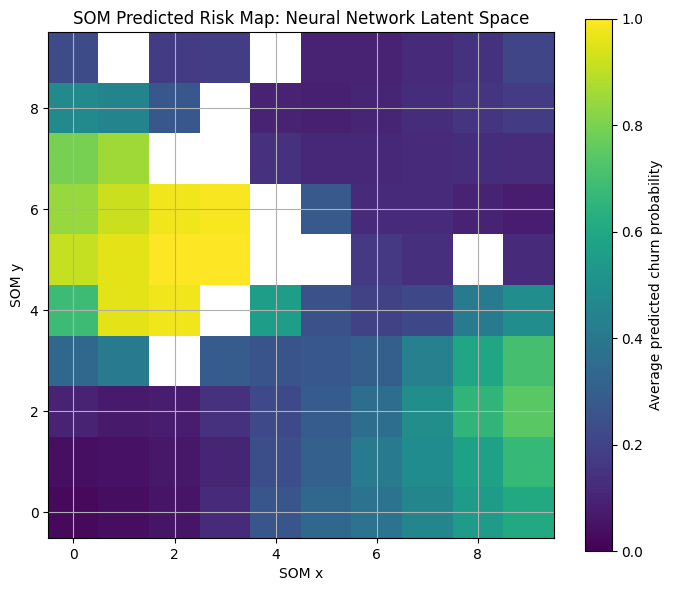

In [22]:
# Self-Organizing Map (SOM) on input features and neural-network latent representations

minisom_module = install_if_missing('minisom', 'minisom')
from minisom import MiniSom


def get_latent_representation(model, X_processed, device=device):
    """
    Extracts the output of the last hidden layer before the final output neuron.
    For this model architecture, model.network[:-1] returns the 16-dimensional latent representation.
    """
    model.eval()
    X_array = X_processed.values if hasattr(X_processed, 'values') else X_processed
    X_tensor = torch.tensor(X_array, dtype=torch.float32).to(device)

    with torch.no_grad():
        latent = model.network[:-1](X_tensor).cpu().numpy()

    return latent


som_sample_size = min(1200, X_test_np.shape[0])
som_idx = RNG.choice(X_test_np.shape[0], size=som_sample_size, replace=False)

X_som_input = X_test_np[som_idx]
y_som = np.array(y_test)[som_idx].astype(int)
probs_som = np.array(test_probs)[som_idx]

X_som_latent = get_latent_representation(model, X_som_input, device=device)

latent_scaler = StandardScaler()
X_som_latent_scaled = latent_scaler.fit_transform(X_som_latent)


def train_som(data, grid_size=10, sigma=1.0, learning_rate=0.5, iterations=1500, seed=42):
    som = MiniSom(
        x=grid_size,
        y=grid_size,
        input_len=data.shape[1],
        sigma=sigma,
        learning_rate=learning_rate,
        random_seed=seed
    )
    som.random_weights_init(data)
    som.train_random(data, iterations)
    return som


def som_churn_rate_grid(som, data, labels, probabilities, grid_size=10):
    counts = np.zeros((grid_size, grid_size))
    churns = np.zeros((grid_size, grid_size))
    avg_prob = np.zeros((grid_size, grid_size))

    for row, label, prob in zip(data, labels, probabilities):
        i, j = som.winner(row)
        counts[i, j] += 1
        churns[i, j] += label
        avg_prob[i, j] += prob

    churn_rate = np.divide(churns, counts, out=np.full_like(churns, np.nan), where=counts > 0)
    avg_probability = np.divide(avg_prob, counts, out=np.full_like(avg_prob, np.nan), where=counts > 0)
    return counts, churn_rate, avg_probability


grid_size = 10
som_input = train_som(X_som_input, grid_size=grid_size, iterations=1200, seed=SEED if 'SEED' in globals() else 42)
som_latent = train_som(X_som_latent_scaled, grid_size=grid_size, iterations=1200, seed=SEED if 'SEED' in globals() else 42)

input_counts, input_churn_rate, input_avg_prob = som_churn_rate_grid(som_input, X_som_input, y_som, probs_som, grid_size=grid_size)
latent_counts, latent_churn_rate, latent_avg_prob = som_churn_rate_grid(som_latent, X_som_latent_scaled, y_som, probs_som, grid_size=grid_size)

plt.figure(figsize=(7, 6))
plt.imshow(input_counts.T, origin='lower')
plt.colorbar(label='Number of customers')
plt.title('SOM Hit Map: Processed Input Space')
plt.xlabel('SOM x')
plt.ylabel('SOM y')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
plt.imshow(latent_counts.T, origin='lower')
plt.colorbar(label='Number of customers')
plt.title('SOM Hit Map: Neural Network Latent Space')
plt.xlabel('SOM x')
plt.ylabel('SOM y')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
plt.imshow(input_churn_rate.T, origin='lower', vmin=0, vmax=1)
plt.colorbar(label='Actual churn rate')
plt.title('SOM Actual Churn Rate: Processed Input Space')
plt.xlabel('SOM x')
plt.ylabel('SOM y')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
plt.imshow(latent_churn_rate.T, origin='lower', vmin=0, vmax=1)
plt.colorbar(label='Actual churn rate')
plt.title('SOM Actual Churn Rate: Neural Network Latent Space')
plt.xlabel('SOM x')
plt.ylabel('SOM y')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
plt.imshow(latent_avg_prob.T, origin='lower', vmin=0, vmax=1)
plt.colorbar(label='Average predicted churn probability')
plt.title('SOM Predicted Risk Map: Neural Network Latent Space')
plt.xlabel('SOM x')
plt.ylabel('SOM y')
plt.tight_layout()
plt.show()

### SOM Interpretation

The SOM analysis gives a global view of how customers are organized in the feature space and in the neural network's learned representation.

The most important comparison is between the input-space SOM and the latent-space SOM:

- The **input-space SOM** shows similarity based on raw standardized and encoded customer attributes.
- The **latent-space SOM** shows similarity after the MLP has transformed customers into a representation optimized for churn prediction.

If churn-risk regions are more concentrated in the latent-space map, this supports the idea that the neural network has learned a meaningful internal representation of customer behavior. From a business perspective, such clusters could later be used for segment-specific retention strategies: for example, different offers for inactive high-balance customers versus older customers with low product engagement.

## 5.5. XAI Summary for Business Use

The XAI extension strengthens the project because it turns the neural network from a black-box classifier into a more transparent decision-support system.

**Global explanation:** permutation importance and SHAP identify the main drivers of churn-risk predictions. These results can be used by management to validate whether the model relies on plausible banking signals.

**Local explanation:** LIME and local SHAP explain why one specific customer receives a high churn-risk score. This is useful for retention managers who need to understand individual cases before contacting customers.

**Representation explanation:** SOM shows whether the MLP organizes customers into meaningful risk regions in latent space. This can support customer segmentation and future campaign personalization.

The final business workflow becomes:

```text
customer data → preprocessing → MLP churn probability → threshold / ranking → retention list → XAI explanation → targeted retention action
```

This makes the solution more operationally realistic: the bank can identify high-risk customers, prioritize them, and explain the main reasons behind the model's recommendation.

# 7. Conclusion with XAI Extension

The original project already solved the core business problem: predicting bank customer churn early enough to support proactive retention. The neural network achieved strong ranking quality and produced a focused retention list rather than requiring the bank to contact the full customer base.

The XAI extension improves the project in three important ways.

First, it adds **global interpretability**. Permutation importance and SHAP show which customer attributes drive churn-risk predictions most strongly. This helps validate that the MLP uses meaningful business signals rather than technical identifiers or random noise.

Second, it adds **local interpretability**. LIME and local SHAP can explain one individual customer's high-risk score. This is important because retention teams need customer-level explanations, not only aggregate metrics.

Third, it adds **representation-level insight**. SOM visualizes how the neural network organizes customers in latent space. This helps demonstrate that the MLP is not only producing probabilities, but also learning a structured representation of customer behavior.

Overall, the final solution is not just a predictive model. It is an interpretable churn-management workflow that supports business decisions:

- identify customers with the highest churn risk;
- prioritize retention campaigns using a business-aware threshold;
- estimate expected financial impact;
- explain both global model behavior and individual customer predictions;
- support future customer segmentation using neural-network representations.

This combination of neural-network modeling, business KPI alignment, and Explainable AI makes the project stronger and more suitable for a high-quality capstone submission.

In [23]:
# Customer-level action list for retention team
action_list = test_results.copy()
action_list['recommended_action'] = np.where(
    action_list['predicted_churn_probability'] >= best_threshold,
    'Contact for retention campaign',
    'Monitor / no immediate action'
)

# Show the highest-risk customers from the test set.
cols_to_show = [
    'predicted_churn_probability', 'recommended_action', 'actual_churn',
    'age', 'country', 'gender', 'balance', 'products_number',
    'active_member', 'credit_score', 'estimated_salary', 'tenure'
]

high_risk_customers = action_list.sort_values(
    'predicted_churn_probability', ascending=False
)[cols_to_show].head(15)

display(high_risk_customers.style.format({
    'predicted_churn_probability': '{:.1%}',
    'balance': '{:,.0f}',
    'estimated_salary': '{:,.0f}'
}))

,predicted_churn_probability,recommended_action,actual_churn,age,country,gender,balance,products_number,active_member,credit_score,estimated_salary,tenure
70,100.0%,Contact for retention campaign,1,58,Germany,Male,"133,745",4,0,738,"28,374",2
5386,100.0%,Contact for retention campaign,1,48,France,Male,"118,317",4,0,642,"78,703",9
5010,100.0%,Contact for retention campaign,1,49,Germany,Male,"121,205",4,1,575,"168,081",7
9540,100.0%,Contact for retention campaign,1,46,Germany,Male,"115,248",4,0,727,"130,752",3
2541,100.0%,Contact for retention campaign,1,61,France,Female,"131,584",4,1,611,"66,238",3
6172,100.0%,Contact for retention campaign,1,43,Germany,Male,"87,613",4,1,568,"107,155",5
9215,100.0%,Contact for retention campaign,1,37,Germany,Female,"134,172",4,1,584,"70,927",10
9255,100.0%,Contact for retention campaign,1,41,Germany,Female,"101,544",4,0,847,"16,025",3
1701,100.0%,Contact for retention campaign,1,50,France,Male,0,4,1,792,"194,701",9
7435,100.0%,Contact for retention campaign,1,50,Spain,Female,"130,555",3,0,610,"184,758",5


In [24]:
# Business impact simulation on the test set
tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()
expected_saved_customers = tp * RETENTION_SUCCESS_RATE
campaign_cost = (tp + fp) * RETENTION_COST
expected_retained_value = expected_saved_customers * CUSTOMER_VALUE_SAVED
expected_net_impact = expected_retained_value - campaign_cost

business_impact = pd.DataFrame({
    'metric': [
        'Customers contacted',
        'True churners targeted',
        'False positives contacted',
        'Churners missed',
        'Expected saved customers',
        'Expected retained value',
        'Campaign cost',
        'Expected net impact'
    ],
    'value': [
        int(tp + fp),
        int(tp),
        int(fp),
        int(fn),
        expected_saved_customers,
        expected_retained_value,
        campaign_cost,
        expected_net_impact
    ]
})

display(business_impact)

print(
    f'With the selected threshold, the model targets {tp + fp} customers in the test set, '
    f'captures {tp} actual churners, and produces an estimated net impact of {expected_net_impact:,.0f} monetary units '
    f'under the stated assumptions.'
)

,metric,value
0,Customers contacted,552.0
1,True churners targeted,292.0
2,False positives contacted,260.0
3,Churners missed,115.0
4,Expected saved customers,73.0
5,Expected retained value,36500.0
6,Campaign cost,27600.0
7,Expected net impact,8900.0


With the selected threshold, the model targets 552 customers in the test set, captures 292 actual churners, and produces an estimated net impact of 8,900 monetary units under the stated assumptions.


## Business Impact Interpretation

The business impact simulation translates the classification results into decision value.

With the selected threshold, the model contacts **552 customers** in the test set and captures **292 actual churners**. Under the illustrative assumptions, this produces an expected net impact of **8,900 monetary units**.

The key point is not the exact number, because the financial assumptions are simplified. The key point is that the notebook demonstrates how a bank can connect model outputs to operational economics:

- value saved from retained churners;
- cost of contacting customers;
- expected success rate of retention actions;
- net campaign impact.

This is what turns the model from a technical classifier into a business decision-support tool.


# 6. Final Conclusion

This capstone project solves a concrete business problem: **early identification of bank customers at risk of churn**. The proposed solution uses a deep neural network for tabular customer-level data and turns model probabilities into an operational retention list.

## Main results

On the holdout test set, the model achieved:

- **ROC-AUC:** 0.8574
- **PR-AUC:** 0.6975
- **Precision:** 0.5290
- **Recall:** 0.7174
- **F1-score:** 0.6090
- **Contact rate:** 27.6%

These results are business-relevant. The model captures **292 out of 407 churners** in the test set while contacting **552 out of 2,000 customers**. In other words, the bank can contact a focused high-risk group instead of launching a broad and expensive campaign to all customers.

The lift analysis is especially important for business value. The highest-risk decile has an **80.0% churn rate**, which is approximately **3.93 times higher** than the average churn rate. This means the neural network is effective at concentrating churners near the top of the ranked customer list.

## Business value

The model can support a practical retention workflow:

1. score all active customers weekly or monthly;
2. sort customers by predicted churn probability;
3. contact customers above the selected threshold;
4. prioritize the highest-risk decile for stronger retention actions;
5. use lower-risk groups for lighter monitoring or automated communication.

Under the illustrative assumptions used in this notebook, the selected threshold produces a positive expected net impact of **8,900 monetary units** on the test set. This should not be interpreted as a final financial forecast. In production, the assumptions should be calibrated using real bank data: customer lifetime value, campaign cost, margin, and observed retention uplift.

## Why the solution is strong

- The project is aligned with a real banking use case: customer retention.
- The dataset has realistic CRM-style customer features rather than toy variables.
- The model is a neural network and follows deep learning design principles.
- The architecture includes nonlinear layers, dropout regularization, early stopping, and class imbalance handling.
- Evaluation goes beyond accuracy and focuses on ROC-AUC, recall, PR-AUC, lift, and business impact.
- The decision threshold is chosen using validation data and business logic instead of the default 0.50 cutoff.
- Interpretability is included through permutation importance and high-risk customer profiles.

## Limitations

The current dataset is static. It does not include transaction history, digital app activity, complaints, customer service interactions, marketing exposure, or time-based behavioral changes.

Another limitation is probability calibration. Some high-risk customers receive probabilities close to 100%. This is acceptable for ranking and prioritization, but in production the probabilities should be calibrated before they are used as exact financial risk estimates.

## Future improvements

- Add transaction-level and app activity features.
- Add time-window features such as balance trend, salary inflow trend, and activity decline.
- Calibrate predicted probabilities using validation data.
- Compare the MLP with gradient boosting as a production benchmark.
- Monitor model drift over time.
- Connect predictions to real retention campaign outcomes for causal impact measurement.
- Estimate customer-specific expected value, so that the bank can prioritize not only churn probability but also expected retention ROI.

## Final business recommendation

The model is strong enough for a pilot retention campaign. The recommended first use case is to score customers monthly, target the top-risk group with retention actions, and measure actual uplift against a control group. This would turn the churn model from a predictive analytics project into a measurable business decision system.
